In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("Data loaded! Shape:", df.shape)

Data loaded! Shape: (7043, 21)


In [2]:
print(df.head())
print("\nShape:", df.shape)
df.info()

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [3]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Nulls in TotalCharges after fix:", df['TotalCharges'].isnull().sum())
df.dropna(subset=['TotalCharges'], inplace=True)
print("Rows remaining:", len(df))

Nulls in TotalCharges after fix: 11
Rows remaining: 7032


In [5]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(df['Churn'].value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


In [6]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical columns:", categorical_cols)
print("\nNumeric columns:", numeric_cols)

Categorical columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']


C:\Users\ravio\AppData\Local\Temp\ipykernel_17536\890313197.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2')


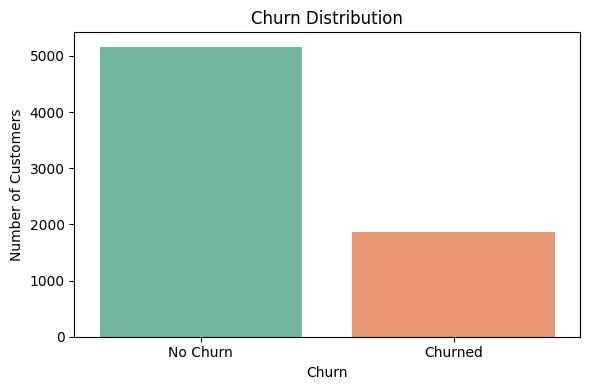

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Churn Distribution')
plt.xticks([0, 1], ['No Churn', 'Churned'])
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

C:\Users\ravio\AppData\Local\Temp\ipykernel_17536\611242457.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[0], palette='Set2')
C:\Users\ravio\AppData\Local\Temp\ipykernel_17536\611242457.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[1], palette='Set2')
C:\Users\ravio\AppData\Local\Temp\ipykernel_17536\611242457.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='TotalCharges', data=df, ax=axes[2], palette='Set2')


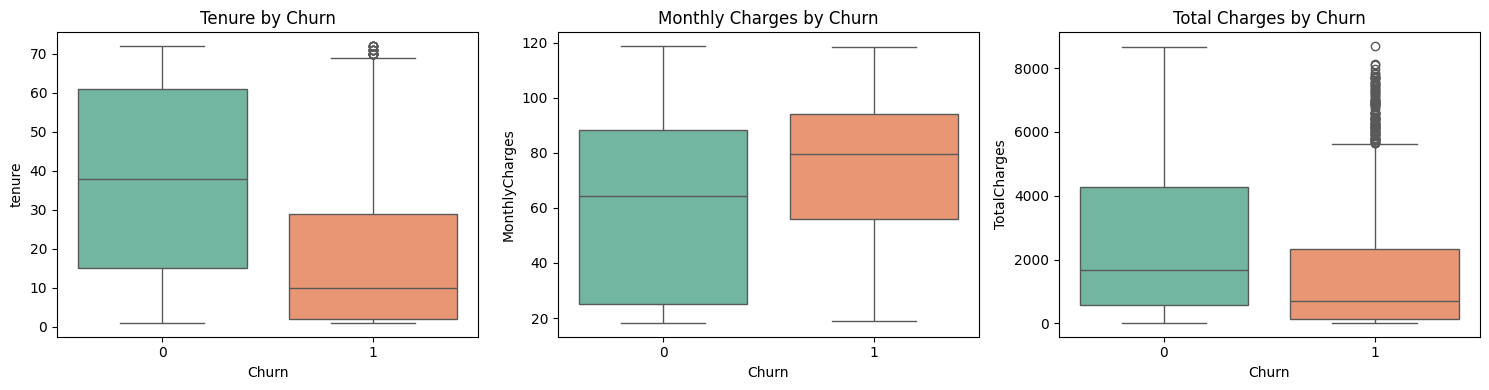

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Tenure by Churn')

sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Monthly Charges by Churn')

sns.boxplot(x='Churn', y='TotalCharges', data=df, ax=axes[2], palette='Set2')
axes[2].set_title('Total Charges by Churn')

plt.tight_layout()
plt.show()

C:\Users\ravio\AppData\Local\Temp\ipykernel_17536\1285986574.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Churn', data=churn_rate, ax=ax, palette='Set2')
C:\Users\ravio\AppData\Local\Temp\ipykernel_17536\1285986574.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Churn', data=churn_rate, ax=ax, palette='Set2')
C:\Users\ravio\AppData\Local\Temp\ipykernel_17536\1285986574.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Churn', data=churn_rate, ax=ax, palette='Set2')


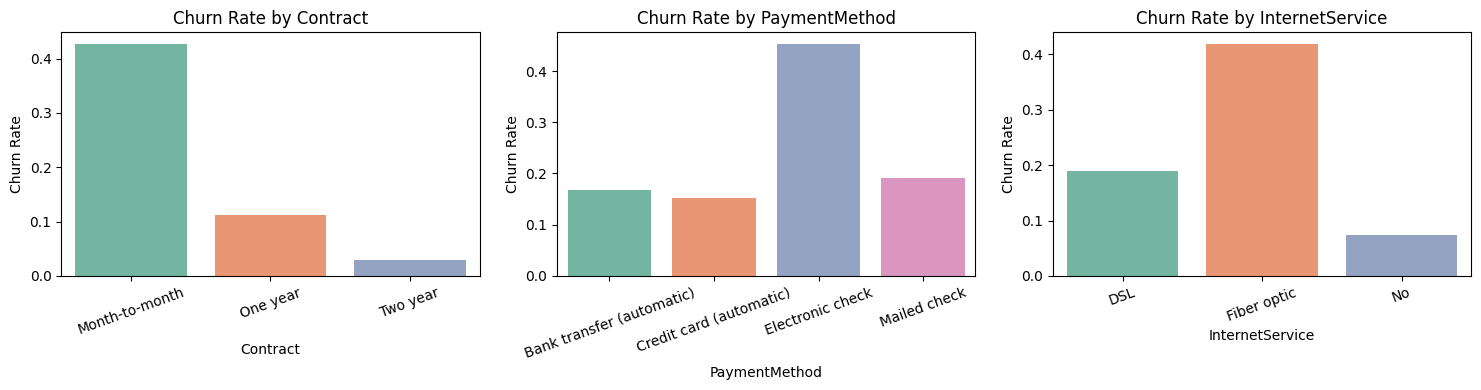

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['Contract', 'PaymentMethod', 'InternetService']):
    churn_rate = df.groupby(col)['Churn'].mean().reset_index()
    sns.barplot(x=col, y='Churn', data=churn_rate, ax=ax, palette='Set2')
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

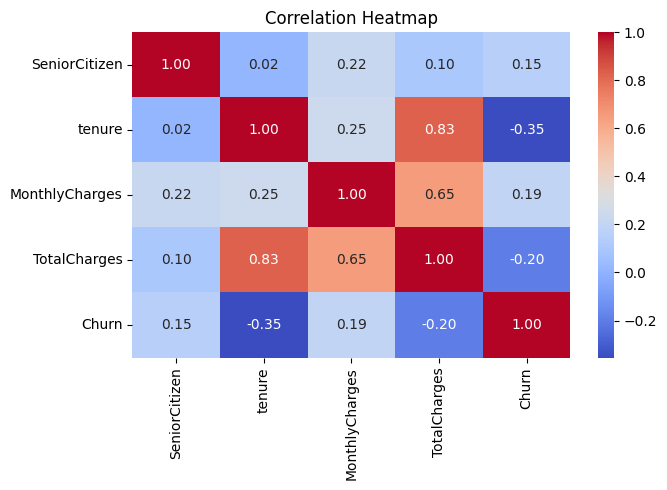

In [10]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [11]:
df_model = df.drop(columns=['customerID'])
df_model = pd.get_dummies(df_model, drop_first=True)
print("Shape after encoding:", df_model.shape)
print(df_model.columns.tolist())

Shape after encoding: (7032, 31)
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [12]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (5625, 30)
Test set size: (1407, 30)


In [13]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


c:\Users\ravio\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[914 119]
 [181 193]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [15]:
import pandas as pd

coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=False)

print("Top 5 factors INCREASING churn:")
print(coefficients.head(5).to_string(index=False))
print("\nTop 5 factors DECREASING churn:")
print(coefficients.tail(5).to_string(index=False))

Top 5 factors INCREASING churn:
                       Feature  Coefficient
   InternetService_Fiber optic     1.067523
           StreamingMovies_Yes     0.357468
               StreamingTV_Yes     0.339343
MultipleLines_No phone service     0.332456
             MultipleLines_Yes     0.279905

Top 5 factors DECREASING churn:
           Feature  Coefficient
    Dependents_Yes    -0.215078
   TechSupport_Yes    -0.366680
OnlineSecurity_Yes    -0.390152
 Contract_One year    -0.752634
 Contract_Two year    -1.296534


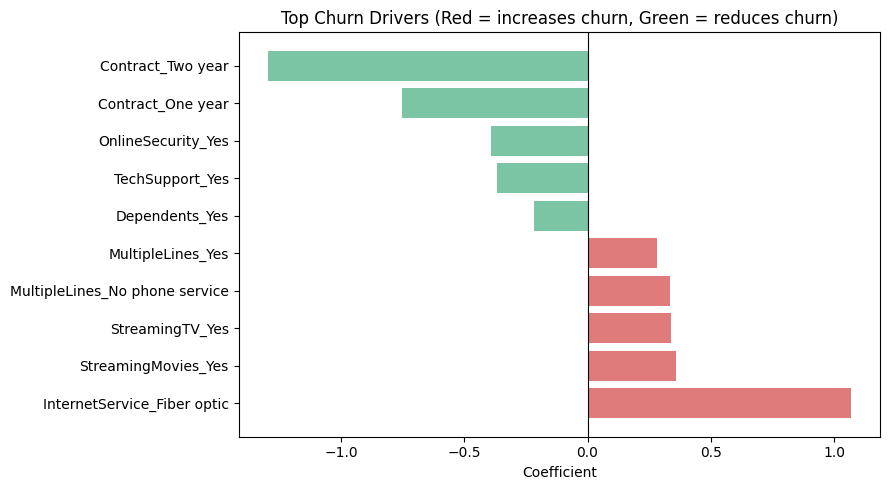

In [16]:
top_features = coefficients.head(5)._append(coefficients.tail(5))

colors = ['#e07b7b' if c > 0 else '#7bc4a4' for c in top_features['Coefficient']]

plt.figure(figsize=(9, 5))
plt.barh(top_features['Feature'], top_features['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top Churn Drivers (Red = increases churn, Green = reduces churn)')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.show()

In [17]:
# Run this to confirm your notebook is complete
print("=" * 50)
print("  CUSTOMER CHURN ANALYSIS — COMPLETE!")
print("=" * 50)
print(f"\n  Dataset:     Telco Customer Churn (Kaggle)")
print(f"  Rows:        7,032 customers")
print(f"  Features:    30 after encoding")
print(f"  Model:       Logistic Regression")
print(f"  Accuracy:    79%")
print(f"\n  Key finding: Fiber optic + month-to-month")
print(f"  contracts are the top churn risk factors.")
print("=" * 50)

  CUSTOMER CHURN ANALYSIS — COMPLETE!

  Dataset:     Telco Customer Churn (Kaggle)
  Rows:        7,032 customers
  Features:    30 after encoding
  Model:       Logistic Regression
  Accuracy:    79%

  Key finding: Fiber optic + month-to-month
  contracts are the top churn risk factors.
